In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
import warnings
warnings.filterwarnings('ignore')
import os
sns.set_style("whitegrid")

In [55]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [56]:
df = pd.read_csv("C:\\Users\\SK\\Downloads\\archive (1)\\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [57]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [58]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [59]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [60]:
df["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

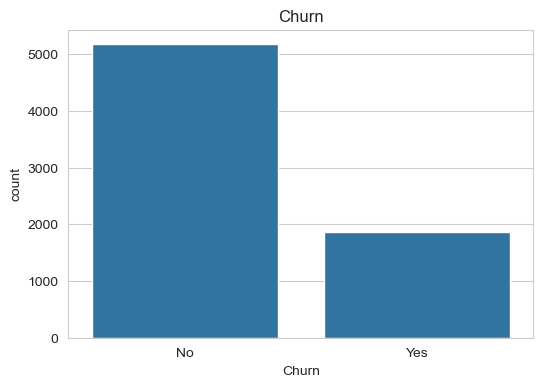

In [61]:
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)
plt.title("Churn")
plt.show()

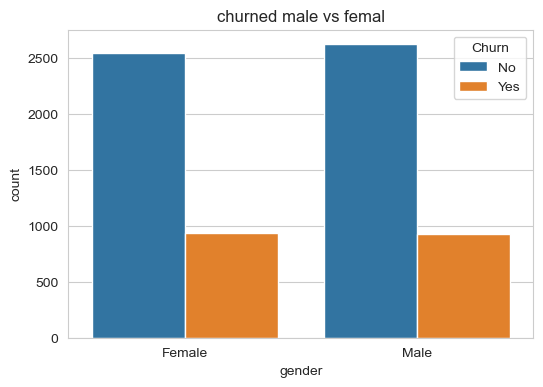

In [62]:
plt.figure(figsize=(6,4))
sns.countplot(x="gender", data=df, hue="Churn")
plt.title("churned male vs femal")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

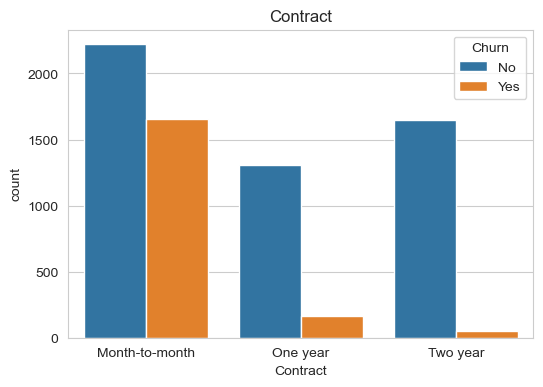

In [63]:
plt.figure(figsize=(6,4))
sns.countplot(x="Contract", data=df, hue="Churn")
plt.title("Contract")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

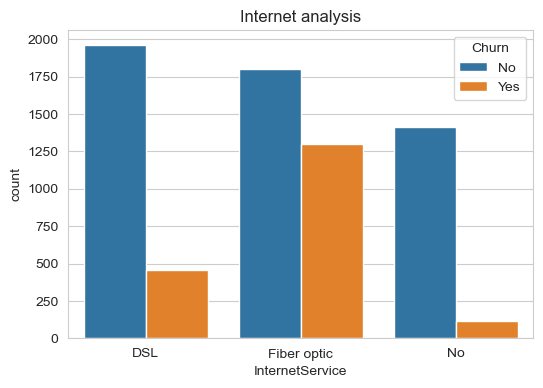

In [64]:
plt.figure(figsize=(6,4))
sns.countplot(x="InternetService", data=df, hue="Churn")
plt.title("Internet analysis")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

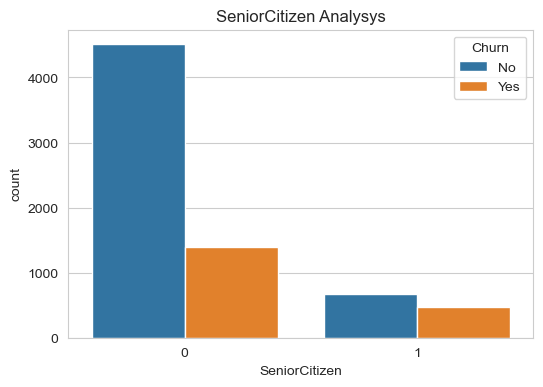

In [65]:
plt.figure(figsize=(6,4))
sns.countplot(x="SeniorCitizen", data=df, hue="Churn")
plt.title("SeniorCitizen Analysys")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

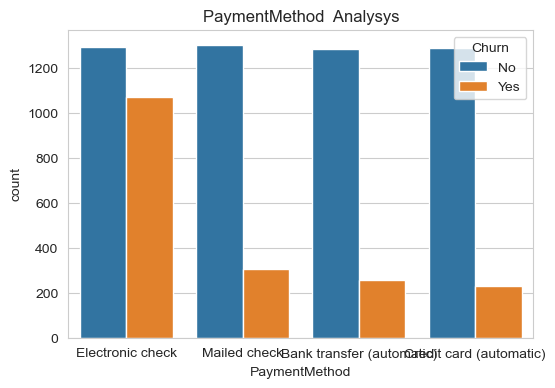

In [66]:
plt.figure(figsize=(6,4))
sns.countplot(x="PaymentMethod", data=df, hue="Churn")
plt.title("PaymentMethod  Analysys")
plt.show

## Data cleaning

In [67]:
df["TotalCharges"].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

In [68]:
pd.to_numeric(df["TotalCharges"], errors="coerce") #here we converted totalcharge col obj to float type

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [69]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce") #here we replaced the missing values with nan
print("TotalCharges",type("TotalCharges"))

TotalCharges <class 'str'>


In [70]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].dtype

dtype('float64')

In [71]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [72]:
df = df.dropna() #here we are dropping the missing values column

In [73]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [74]:
df.shape

(7032, 21)

In [75]:
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})
#print(df["Churn"])
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [99]:
df = pd.read_csv(r"C:\\Users\\SK\\Downloads\\archive (1)\\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df_raw = df.copy() 

In [100]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [101]:
df = df.dropna()

In [102]:
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [103]:
df.select_dtypes(include="object").columns

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [104]:
df = df.drop("customerID", axis=1)

In [105]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [106]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cols = ["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]

for col in cols:
    df[col] = le.fit_transform(df[col])

In [107]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [108]:
df = pd.get_dummies(df, columns=["MultipleLines", "InternetService", 
                                  "OnlineSecurity", "OnlineBackup",
                                  "DeviceProtection", "TechSupport", 
                                  "StreamingTV", "StreamingMovies",
                                  "Contract", "PaymentMethod"], 
                                   drop_first=True,
                                   dtype=int)

In [109]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,0,0,1,0


In [110]:
df.shape

(7032, 31)

In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   PaperlessBilling                       7032 non-null   int64  
 7   MonthlyCharges                         7032 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7032 non-null   int64  
 10  MultipleLines_No phone service         7032 non-null   int64  
 11  MultipleL

In [112]:
X = df.drop("Churn", axis=1)  # everything except Churn
y = df["Churn"]                # only Churn column

In [113]:
X.shape

(7032, 30)

In [114]:
y.shape

(7032,)

In [115]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [116]:
print(X_train.shape)
print(X_test.shape)

(5625, 30)
(1407, 30)


In [117]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [118]:
X_train[0]

array([-1.01378388, -0.43758982, -0.9624811 , -0.65368396,  0.43467403,
       -3.04070742,  0.83139683, -0.51862031, -0.08790784,  3.04070742,
       -0.84554067, -0.88544634, -0.52984687, -0.52984687, -0.63517172,
       -0.52984687, -0.7281455 , -0.52984687,  1.38474948, -0.52984687,
       -0.63875661, -0.52984687,  1.26181056, -0.52984687,  1.2472596 ,
       -0.51827235, -0.5611299 , -0.52764485, -0.71475753, -0.54742719])

In [119]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

LogisticRegression()

In [120]:
y_pred = lr.predict(X_test)

In [121]:
print(y_pred)

[0 0 1 ... 0 0 0]


In [122]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification Report
print(classification_report(y_test, y_pred))

Accuracy: 0.7874911158493249
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [123]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.7867803837953091


In [127]:
pip install xgboost

In [128]:
import xgboost as xgb

# Create model
xgb_model = xgb.XGBClassifier(random_state=42)

# Train model
xgb_model.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test)

# Accuracy
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_rf))

XGBoost Accuracy: 0.7867803837953091


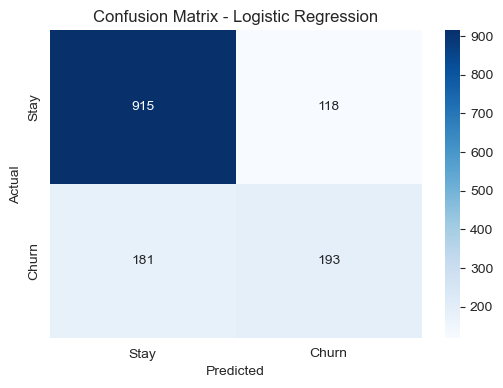

In [129]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Stay", "Churn"],
            yticklabels=["Stay", "Churn"])
plt.title("Confusion Matrix - Logistic Regression")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

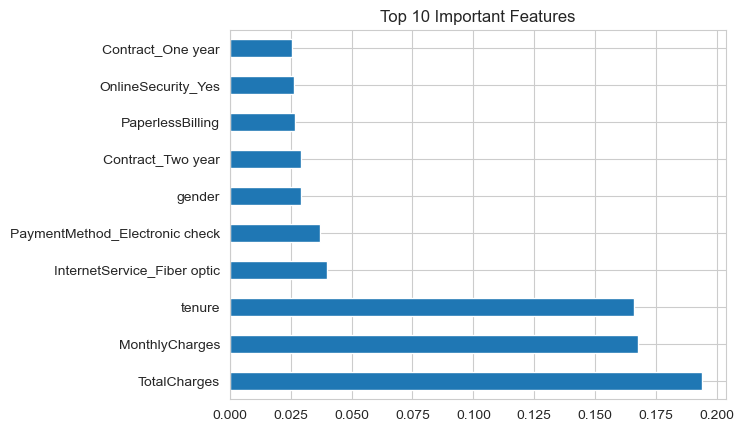

In [130]:
feat_importance = pd.Series(rf.feature_importances_, 
                            index=X.columns)
feat_importance.nlargest(10).plot(kind="barh")
plt.title("Top 10 Important Features")
plt.show()

In [131]:
pip install streamlit

In [135]:
import os
print(os.getcwd())

C:\Users\SK


In [136]:
import os
print(os.listdir())

['.anaconda', '.conda', '.condarc', '.continuum', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.python_history', 'anaconda3', 'anaconda_projects', 'app.py', 'AppData', 'Application Data', 'churn_analysis.ipynb', 'Contacts', 'Cookies', 'demo.txt', 'Desktop', 'Documents', 'Downloads', 'Favorites', 'Function.ipynb', 'IntelGraphicsProfiles', 'Links', 'Local Settings', 'Music', 'My Documents', 'netflix_titles.csv', 'NetHood', 'New folder', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TM.blf', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'numpyprojects.ipynb', 'OneDrive', 'pandasassignment.ipynb', 'Pictures', 'predefinedmodules.ipynb', 'PrintHood', 'probability.ipynb', 'project.ipynb', 'PythonAssignment.ipynb', 'pythonfirstassignment.ipynb', 'Recent'

In [137]:
import os
os.makedirs("models", exist_ok=True)
print("✅ Models folder created!")

✅ Models folder created!


In [139]:
import pickle

with open("models/churn_model.pkl", "wb") as f:
    pickle.dump(rf, f)

with open("models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("✅ Model and scaler saved!")

✅ Model and scaler saved!


In [140]:
import pickle

with open("models/churn_model.pkl", "wb") as f:
    pickle.dump(rf, f)

with open("models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("✅ Model and scaler saved!")

✅ Model and scaler saved!


In [141]:
import os
print(os.listdir("models"))

['churn_model.pkl', 'scaler.pkl']


In [ ]:
#streamlit run APP.py (run this in anaconda prompt to seee the result of streamlit)